# Medidas de bondad de ajuste
En este script se hace un resumen sobre las medidas de bondad de ajuste para dos tipos de problema: clasificación binaria y regresión (predicción de variable continua).

## Evaluando un problema de clasificación binaria
_Ejemplo_ Se trata de clasificar 6 correos como _Spam-No Spam_. Los datos etiquetados que se tienen son _real={Spam, Spam, Spam, No Spam, Spam, No Spam}_, mientras que la predicción hecha es _pred={Spam, Spam, No Spam, Spam, No Spam, No Spam}_.

Lo primero que hay que hacer es convertir esas etiquetas a 1 (_Spam_/clase de interés) y 0 (_No Spam_). 

In [2]:
y_true = [1, 1, 1, 0, 1, 0]
y_pred = [1, 1, 0, 1, 0, 0]

Las métricas de evaluación están en la sub-librería, _sklearn.metrics_ y la matriz de confusión la podemos dibujar desde _matplotlib.pyplot_.

In [4]:
from sklearn.metrics import confusion_matrix
#.rabvel() convierte un arreglo de varias dimensiones en una secuencia lineal de elementos. 
#En este caso, una matriz de confusión 2x2 a un array con 4 elementos
#es más rápido que .flatten() porque no hace copias
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel() 

In [6]:
#otra forma de obtener los elementos de la matriz de confusión sin aplanarla
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp= cm[0][0], cm[0][1], cm[1][0], cm[1][1]     
print(f"Los elementos de la matriz de confusión son tn: {tn}; fp: {fp}; fn: {fn} y tp: {tp}.")

Los elementos de la matriz de confusión son tn: 1; fp: 1; fn: 2 y tp: 2.


Una vez calculados los elementos de la matriz de confusión, se pueden represenar para mejorar la visualización

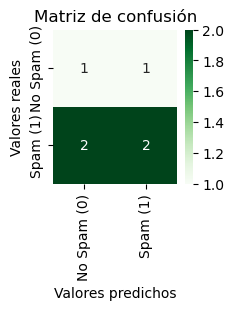

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
clases = ['No Spam (0)', 'Spam (1)']

# Crear un mapa de calor para mejorar la visualización
plt.figure(figsize=(2, 2))
sns.heatmap(cm, annot=True, cmap='Greens', fmt='g', xticklabels=clases, yticklabels=clases)
plt.xlabel('Valores predichos')
plt.ylabel('Valores reales')
plt.title('Matriz de confusión')
plt.show()
plt.close()

In [10]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_true, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.5


In [12]:
from sklearn.metrics import precision_score
precision=precision_score(y_true, y_pred)
print(f"Precisión: {precision}")

Precisión: 0.6666666666666666


In [14]:
from sklearn.metrics import recall_score
recall = recall_score(y_true, y_pred)
print(f"Recall/sensibilidad: {recall}")

Recall/sensibilidad: 0.5


In [16]:
from sklearn.metrics import f1_score
f1=f1_score(y_true, y_pred)
print(f"F1_score: {f1}")

F1_score: 0.5714285714285714


También se pueden calcular las métricas de forma "manual" a partir de los elementos de la matriz de confusión

In [19]:
accuracy=(tp+tn)/(tp+tn+fp+fn)
print(f"Accuracy: {accuracy}")
precision=tp/(tp+fp)
print(f"Precisión: {precision}")
recall=tp/(tp+fn)
print(f"Recall/sensibilidad: {recall}")
f1=2*((precision*recall)/(precision+recall))
print(f"F1_score: {f1}")
especifidad = tn / (tn + fp)
print(f"Especificidad: {especifidad}")

Accuracy: 0.5
Precisión: 0.6666666666666666
Recall/sensibilidad: 0.5
F1_score: 0.5714285714285715
Especificidad: 0.5


In [21]:
from sklearn.metrics import roc_curve, auc
#roc_curve calcula las tasas fpr y tpr para distintos punto de corte, establecidos por el sistema dependiendo de los datos
fpr, tpr, thresholds = roc_curve(y_true, y_pred)
print(f"Tasa de falsos positivos: {fpr}")
print(f"Tasa de verdaderos positivos: {tpr}")
print(f"Puntos de corte (thresholds): {thresholds}")

Tasa de falsos positivos: [0.  0.5 1. ]
Tasa de verdaderos positivos: [0.  0.5 1. ]
Puntos de corte (thresholds): [inf  1.  0.]


In [23]:
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc}")
print('El valor del AUC nos dice que el modelo ha hecho una clasificación aleatoria')

AUC: 0.5
El valor del AUC nos dice que el modelo ha hecho una clasificación aleatoria


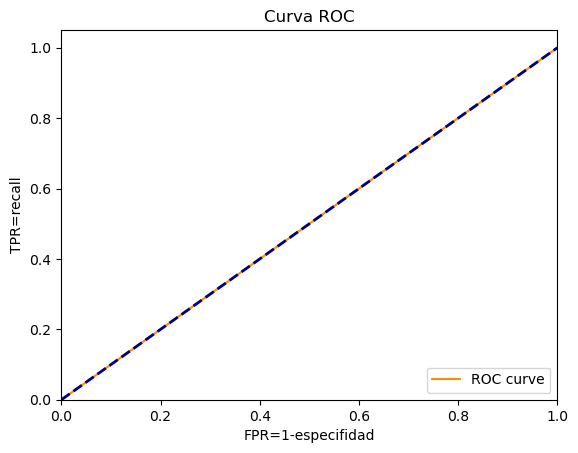

In [28]:
plt.figure()
plt.plot(fpr, tpr, color='darkorange',
         label='ROC curve')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') #lw indica el grosor de la línea. la línea naranja es la referencia de la clasificación aleatoria
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('FPR=1-especifidad')
plt.ylabel('TPR=recall')
plt.title('Curva ROC')
plt.legend(loc="lower right")
plt.show()

## Evaluando un problema de predicción de variable continua
_Ejemplo_. Supongamos que se quiere analizar la predicción hecha sobre los precios de 4 viviendas.
Los datos reales, en miles de euros, son (300, 450, 200, 500), y los datos predichos son (320, 430, 210, 490).


In [30]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# Datos reales (precios reales de las viviendas en miles de euros)
y_true = np.array([300, 450, 200, 500])
# Datos predichos (precios predichos por el modelo en miles de euros)
y_pred = np.array([320, 430, 210, 490])

In [34]:
 # 1. Calcular el MSE (Error Cuadrático Medio)
# --------------------
# Fórmula manual: MSE = promedio((y_true - y_pred)^2)
mse_manual = np.mean((y_true - y_pred) ** 2)
print(f"MSE (manual): {mse_manual}")
# Usando scikit-learn
mse_sklearn = mean_squared_error(y_true, y_pred)
print(f"MSE (scikit-learn): {mse_sklearn}")

# 2. Calcular el RMSE (Raíz del Error Cuadrático Medio)
# --------------------
# Fórmula manual: RMSE = sqrt(MSE)
rmse_manual = np.sqrt(mse_manual)
print(f"RMSE (manual): {rmse_manual}")

# Usando scikit-learn (calculando la raíz del MSE)
rmse_sklearn = np.sqrt(mse_sklearn)
print(f"RMSE (scikit-learn): {rmse_sklearn}")


# 3. Calcular el MAE (Error Absoluto Medio)
# --------------------
# Fórmula manual: MAE = promedio(|y_true - y_pred|)
mae_manual = np.mean(np.abs(y_true - y_pred))
print(f"MAE (manual): {mae_manual}")

# Usando scikit-learn
mae_sklearn = mean_absolute_error(y_true, y_pred)
print(f"MAE (scikit-learn): {mae_sklearn}")

# 4. Calcular el R2 (Coeficiente de Determinación)
# --------------------
# Fórmula manual: R2 = 1 - (SS_res / SS_tot)
# SS_res = suma((y_true - y_pred)^2)
# SS_tot = suma((y_true - promedio(y_true))^2)
ss_res = np.sum((y_true - y_pred) ** 2)
ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
r2_manual = 1 - (ss_res / ss_tot)
print(f"R² (manual): {r2_manual}")

# Usando scikit-learn
r2_sklearn = r2_score(y_true, y_pred)
print(f"R² (scikit-learn): {r2_sklearn}")


MSE (manual): 250.0
MSE (scikit-learn): 250.0
RMSE (manual): 15.811388300841896
RMSE (scikit-learn): 15.811388300841896
MAE (manual): 15.0
MAE (scikit-learn): 15.0
R² (manual): 0.9824175824175824
R² (scikit-learn): 0.9824175824175824
